# CharXiv Modeling, Bootstrap Stability of the Tuned Families (follow-up to Checkpoint 4)

Notebook 17 tuned four model families for each real target on the single 800-item training split and
found no flexible model clearly beating the regularized linear one. Because the dataset is small, those
numbers could reflect the one particular training draw rather than a stable property of the problem.
This notebook resamples the training set with replacement 30 times, re-runs the exact notebook-17
tuning on each resample for the two real targets, and asks whether the ROC-AUC levels and the ordering
across families hold up. GPT-4o-Random is the untuned control and is not bootstrapped.

For each bootstrap sample the four tunable families are tuned with the same nested, paper-grouped
cross-validation used in notebook 17 (`src.models.tune.nested_cv_auc`), for each real target. The
outputs are a per-sample results table, one ROC-AUC histogram grid per target with the 30-sample mean
and the original-sample value marked, and a table of 95 percent percentile bootstrap confidence
intervals.

This notebook runs in the `charxiv-model` conda environment because one of the families is XGBoost. On
this machine the duplicate OpenMP runtime requires `KMP_DUPLICATE_LIB_OK=TRUE`. The 200-item test set
stays sealed, and nothing here reads it.

## 1. Setup

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # duplicate OpenMP runtime on this Intel Mac
import sys, warnings, ast, time
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import src.features.preprocessing as P
from src.splits.splitters import ItemHoldoutSplit
from src.eval.core import evaluate, METRIC_COLS
from src.models import registry, tune
%matplotlib inline

RESULTS = ROOT / "results"
BOOT = RESULTS / "bootstrap"; BOOT.mkdir(parents=True, exist_ok=True)
splitter = ItemHoldoutSplit(5, 3)

N_SAMPLES = 30              # bootstrap resamples of the training set
BASE_SEED = 20260618       # same seed lineage as the fixed 800/200 split
REAL = ["GPT-4o", "Claude-3-5-Sonnet"]
SLUG = {"GPT-4o": "gpt4o", "Claude-3-5-Sonnet": "claude"}

con = P.connect(); train_ids, test_ids = P.get_split(con)
df = P.make_design_matrix(con, train_ids)   # one row per item
con.close()

item_rows = {item: g for item, g in df.groupby("item_id", sort=False)}
unique_items = np.array(sorted(item_rows))
print("xgboost available:", registry.has_xgboost(), "| tuned families:", registry.TUNED_FAMILIES)
print("items:", len(unique_items), "| real targets bootstrapped:", REAL)

xgboost available: True | tuned families: ['logistic_regularized', 'random_forest', 'hist_gb', 'xgboost']
items: 800 | real targets bootstrapped: ['GPT-4o', 'Claude-3-5-Sonnet']


## 2. Bootstrap resampling of the training set

Each bootstrap sample draws as many items as there are training items (800) with replacement.
A duplicated item keeps its `paperid`, so the paper-grouped cross-validation still places every copy of
an item in the same fold and no paper straddles a train and test fold. The same draw is reused for both
real targets so their scores are paired within a sample. The only cost is a mild, expected optimism from
duplicated rows appearing in both the train and test portions of the nested folds, inherent to the
bootstrap and shared by all families.

In [2]:
def bootstrap_sample(b):
    rng = np.random.default_rng(BASE_SEED + b)
    drawn = rng.choice(unique_items, size=len(unique_items), replace=True)
    return pd.concat([item_rows[i] for i in drawn], ignore_index=True)

_chk = bootstrap_sample(0)
assert _chk.shape == df.shape, (_chk.shape, df.shape)
assert set(_chk.item_id).isdisjoint(set(test_ids)), "sealed test id leaked into a bootstrap sample!"
print("sample 0 rows:", _chk.shape, "| distinct items drawn:", _chk.item_id.nunique())

sample 0 rows: (800, 21) | distinct items drawn: 505


## 3. Tuning framework

`tune_one` reproduces notebook 17 exactly: it runs the nested, paper-grouped tuning for one family on
one target and reads the primary key performance indicator (ROC-AUC) off the untouched outer folds,
then computes the secondary indicators with the modal winning hyperparameters held fixed across the
same folds. The cross-validation machinery is identical for every sample.

In [3]:
def tuned_factory(family, modal_params):
    params = {k.replace("clf__", ""): v for k, v in ast.literal_eval(modal_params).items()}
    def factory():
        est = registry.FACTORIES[family]()
        est.set_params(**params)
        return est
    return factory

def tune_one(family, d):
    """Nested-CV tune one family on d (a design matrix with a set 'y' column)."""
    make_pre = lambda: P.build_preprocessor()
    res = tune.nested_cv_auc(d, make_pre, registry.FACTORIES[family](), registry.GRIDS[family],
                             splitter, inner_k=3)
    summary, _, _ = evaluate(d, make_pre, tuned_factory(family, res["modal_best_params"]), splitter)
    row = {"family": family,
           "roc_auc": round(res["roc_auc"], 4), "roc_auc_sd": round(res["roc_auc_sd"], 4),
           "modal_best_params": res["modal_best_params"]}
    row.update({c: round(float(summary[c]), 4) for c in METRIC_COLS if c != "roc_auc"})
    return row

## 4. Run the 30 bootstrap samples

For every bootstrap sample each family is tuned on the same draw for each real target, so the scores
within a sample are paired. Results are appended to `results/bootstrap/bootstrap_tuning.csv` after each
sample so a long run can be inspected while in progress. This is the expensive step.

In [4]:
CSV = BOOT / "bootstrap_tuning.csv"
COLS = ["sample_idx", "target", "family", "roc_auc", "roc_auc_sd", "bal_acc", "f1",
        "modal_best_params", "seed"]

records = []
t0 = time.time()
for b in range(N_SAMPLES):
    df_b = bootstrap_sample(b)
    tb = time.time()
    for target in REAL:
        d = df_b.copy(); d["y"] = d[P.ycol(target)].to_numpy()
        for fam in registry.TUNED_FAMILIES:
            row = tune_one(fam, d)
            row.update({"sample_idx": b, "target": target, "seed": BASE_SEED + b})
            records.append(row)
    pd.DataFrame(records)[COLS].to_csv(CSV, index=False)
    print(f"sample {b:2d}/{N_SAMPLES-1}  ({time.time()-tb:.0f}s, elapsed {time.time()-t0:.0f}s)")
print(f"\nfinished {N_SAMPLES} samples in {(time.time()-t0)/60:.1f} min -> {CSV}")

boot = pd.DataFrame(records)[COLS]
print("rows:", len(boot), "(expected", N_SAMPLES * len(REAL) * len(registry.TUNED_FAMILIES), ")")

sample  0/29  (138s, elapsed 138s)


sample  1/29  (141s, elapsed 278s)


sample  2/29  (147s, elapsed 425s)


sample  3/29  (146s, elapsed 571s)


sample  4/29  (136s, elapsed 707s)


...

sample 25/29  (132s, elapsed 3806s)


sample 26/29  (130s, elapsed 3936s)


sample 27/29  (140s, elapsed 4076s)


sample 28/29  (141s, elapsed 4217s)


sample 29/29  (142s, elapsed 4359s)

finished 30 samples in 72.7 min -> /Users/everett/Documents/GitHub/summer26-ai-faithfulness-in-scientific-reasoning-private/results/bootstrap/bootstrap_tuning.csv
rows: 240 (expected 240 )


## 5. ROC-AUC histograms per target

For each real target, one histogram per family shows the distribution of nested cross-validated ROC-AUC
across the 30 bootstrap samples. The solid line marks the 30-sample mean and the dashed line marks the
value that family reached on the original training sample in notebook 17 (from
`results/model_comparison.csv`). When the original value sits near the center of the bootstrap
distribution, the notebook-17 result is a typical draw rather than a lucky one.

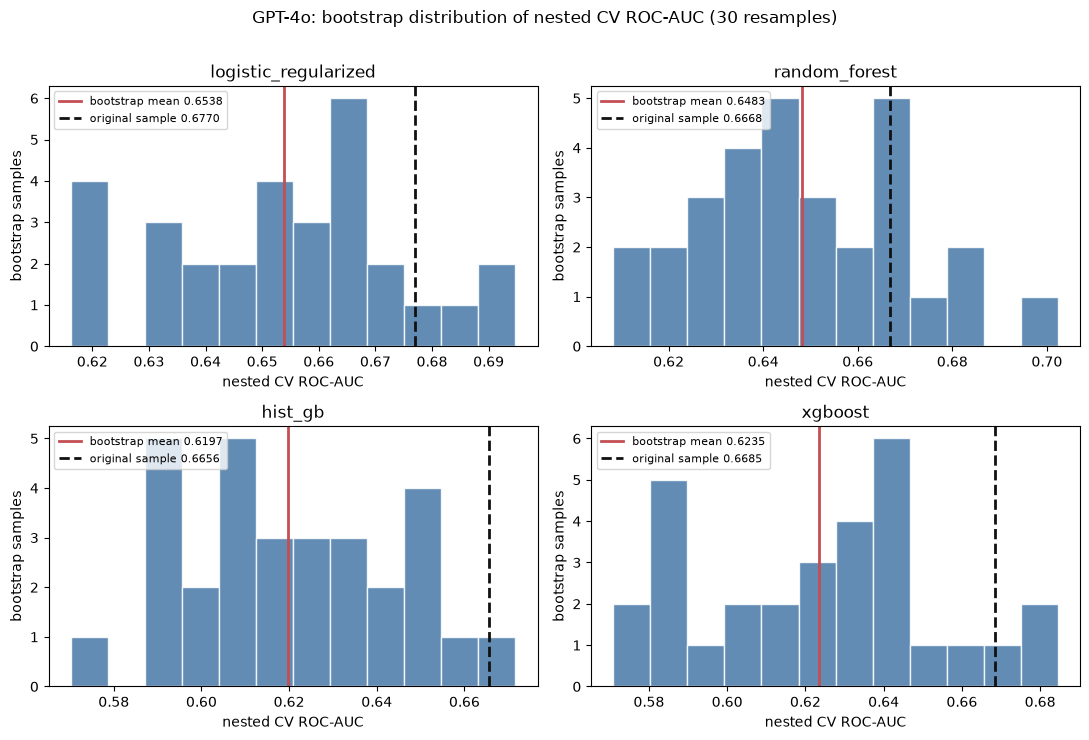

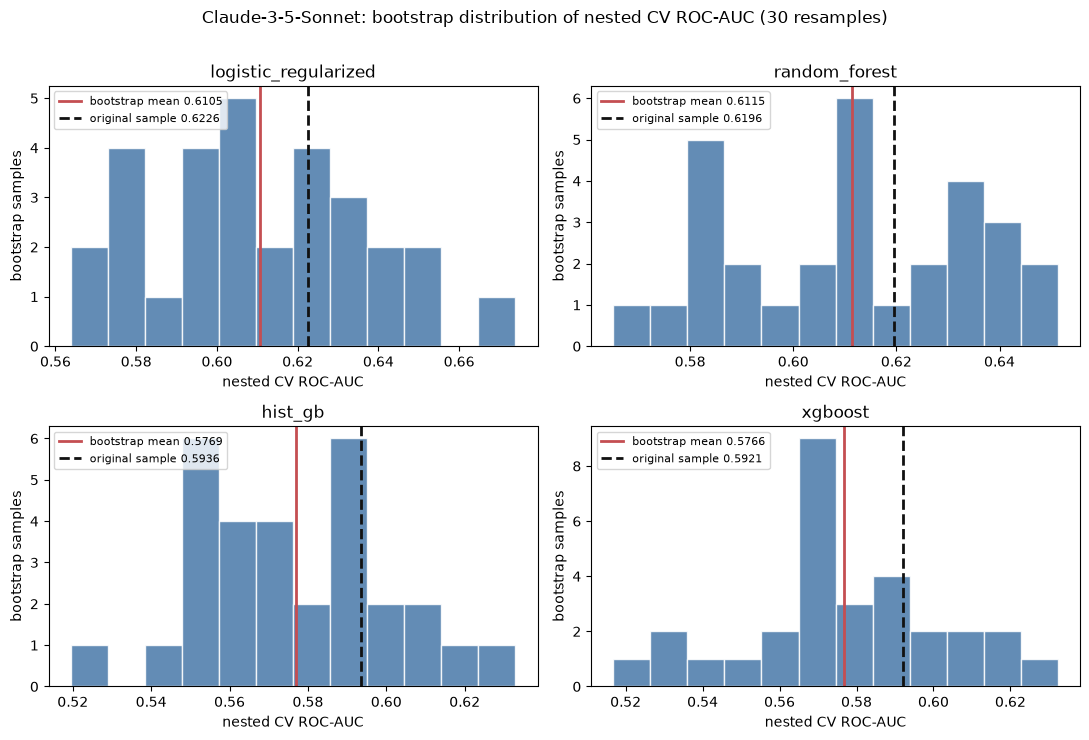

In [5]:
mc = pd.read_csv(RESULTS / "model_comparison.csv").query("config == 'tuned'")
families = registry.TUNED_FAMILIES

for target in REAL:
    orig = mc[mc.target == target].set_index("family")["roc_auc"].to_dict()
    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
    for ax, fam in zip(axes.ravel(), families):
        vals = boot.loc[(boot.target == target) & (boot.family == fam), "roc_auc"].to_numpy()
        ax.hist(vals, bins=12, color="#4878a8", edgecolor="white", alpha=0.85)
        m, o = vals.mean(), orig.get(fam, np.nan)
        ax.axvline(m, color="#c44e52", lw=2, label=f"bootstrap mean {m:.4f}")
        ax.axvline(o, color="#111111", lw=2, ls="--", label=f"original sample {o:.4f}")
        ax.set_title(fam); ax.set_xlabel("nested CV ROC-AUC"); ax.set_ylabel("bootstrap samples")
        ax.legend(fontsize=8, loc="upper left")
    fig.suptitle(f"{target}: bootstrap distribution of nested CV ROC-AUC (30 resamples)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(BOOT / f"roc_auc_hist__{SLUG[target]}.png", dpi=130)
    plt.show()

## 6. Ninety-five percent bootstrap confidence intervals

The percentile bootstrap confidence interval for a family is the interval between the 2.5th and 97.5th
percentiles of its 30 ROC-AUC values, reported per target next to the bootstrap mean, the bootstrap
standard deviation, and the original-sample value. A narrow interval that comfortably contains the
original value indicates a stable result; heavily overlapping intervals across families indicate the
small differences seen in notebook 17 are not meaningful.

In [6]:
ci_rows = []
for target in REAL:
    orig = mc[mc.target == target].set_index("family")["roc_auc"].to_dict()
    for fam in families:
        vals = boot.loc[(boot.target == target) & (boot.family == fam), "roc_auc"].to_numpy()
        lo, hi = np.percentile(vals, [2.5, 97.5])
        ci_rows.append({"target": target, "family": fam, "n_samples": len(vals),
                        "roc_auc_mean": round(float(vals.mean()), 4),
                        "roc_auc_sd": round(float(vals.std(ddof=1)), 4),
                        "ci95_lo": round(float(lo), 4), "ci95_hi": round(float(hi), 4),
                        "original_sample": round(float(orig.get(fam, np.nan)), 4)})
ci = pd.DataFrame(ci_rows).sort_values(["target", "roc_auc_mean"], ascending=[True, False])
ci.to_csv(BOOT / "roc_auc_ci.csv", index=False)
print("wrote", BOOT / "roc_auc_ci.csv")
display(ci.set_index(["target", "family"]))

wrote /Users/everett/Documents/GitHub/summer26-ai-faithfulness-in-scientific-reasoning-private/results/bootstrap/roc_auc_ci.csv


n_samples  roc_auc_mean  roc_auc_sd  \
target            family                                                      
Claude-3-5-Sonnet random_forest                30        0.6115      0.0236   
                  logistic_regularized         30        0.6105      0.0269   
                  hist_gb                      30        0.5769      0.0253   
                  xgboost                      30        0.5766      0.0268   
GPT-4o            logistic_regularized         30        0.6538      0.0216   
                  random_forest                30        0.6483      0.0226   
                  xgboost                      30        0.6235      0.0309   
                  hist_gb                      30        0.6197      0.0248   

                                        ci95_lo  ci95_hi  original_sample  
target            family                                                   
Claude-3-5-Sonnet random_forest          0.5721   0.6485           0.6196  
                  logistic_regularized   0.5681   0.6567           0.6226  
                  hist_gb                0.5397   0.6255           0.5936  
                  xgboost                0.5251   0.6222           0.5921  
GPT-4o            logistic_regularized   0.6163   0.6905           0.6770  
                  random_forest          0.6107   0.6882           0.6668  
                  xgboost                0.5743   0.6782           0.6685  
                  hist_gb                0.5836   0.6596           0.6656

## 7. Findings

Read the histograms and the confidence-interval table together, per target. If each family's
original-sample ROC-AUC falls near the center of its bootstrap distribution, the notebook-17 numbers are
typical draws rather than artifacts of the one training sample. If the four families' 95 percent
intervals overlap heavily, the small ordering differences reported in notebook 17 are within sampling
noise, which reinforces the Checkpoint 4 decision that the extra model complexity is not justified. The
per-sample table in `results/bootstrap/bootstrap_tuning.csv` also records the balanced accuracy, F1, and
modal winning hyperparameters for every sample, target, and family.

In [7]:
# Guardrail: the sealed test set never entered any bootstrap design matrix.
seen = set()
for b in range(N_SAMPLES):
    seen |= set(bootstrap_sample(b).item_id)
assert seen.isdisjoint(set(test_ids)), "a sealed test id entered a bootstrap sample!"
print("OK: the 200 sealed test ids never entered any bootstrap design matrix.")

OK: the 200 sealed test ids never entered any bootstrap design matrix.
